#**Gambaran Besar Sistem**

**1. Machine Learning**

Menggunakan Model Random Forest tambahin lagi
Menggunakan data yang di dapatkan dari kanggle, isi data yang di gunakan sebagai input meliputi:
* Minat
* Hard Skill
* Soft Skill
* Mata Pelajaran

Output:
* Label
contoh: **Komputer dan Teknologi**


**2. Rule Based**

Menggunakan data yang menyesesuaikan Pendidikan di Indonesia.
Jurusan
Ekstrakurikuler
Hobi
Personality

Output yang akan di dapatkan **Skor Bidang**
Contohnya

Komputer dan Teknologi = 40
Teknik = 10
Seni = 5

3. Scorring
Hal ini Menggabungkan hasil dari Prediksi Random Forest dengan Rules Based, lalu hasil tersebut di rangkingkan


# **1. Data Collection**
# Tujuan
Mengumpulkan dataset relevan yang akan digunakan sebagai dasar dalam pembangunan sistem rekomendasi bidang studi dan karir bagi siswa SMA/SMK yang akan melanjutkan pendidikan ke perguruan tinggi.


# Dataset
Dataset ini berasal dari Kaggle: Dataset Career Recommendation
Sumber: https://www.kaggle.com/datasets/breejeshdhar/career-recommendation-dataset




Import Library dan Dataset

In [ ]:
!pip install kagglehub

In [ ]:
import pandas as pd
import numpy as np
import os

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import pickle

import kagglehub
import pandas as pd
import os

In [ ]:
#mendownload
path = kagglehub.dataset_download(
    "breejeshdhar/career-recommendation-dataset"
)

#membaca dataset
data1_df = pd.read_csv(
    os.path.join(path, "career_recommender.csv")
)


Using Colab cache for faster access to the 'career-recommendation-dataset' dataset.


# **2. Data Understanding**
Data Understanding bertujuan untuk memhami karakteristik dataset yang digunakan, meliputi stuktur data, jumlah data, tipe data, serta mengidentifikasi adanya data kosong (missing value) maupun ketidakkonsistenan data sebelum dilakukan proses processing dan pemodelan.

**2.1 Melihat Struktur Dataset**

Digunakan untuk melihat beberapa baris dataset sehingga dapat diketahui bentuk data yang tersedia.

**2.2 Melihat Nama Kolom**

Digunakan untuk mengidentifikasi nama kolom asli yang terdapat pada dataset karena dataset berasal dari survei luar negeri, nama kolom masih menggunakan kalimat pertanyaan yang panjang

**2.3 Melihat  Data Kosong**
Bertujuan mengetahui jumlah missing value pada masing-masing atribut.

**2.4 Informasi Dataset**

Digunakan untuk melihat
*   Jumlah Data
*   Tipe Data
*   Data Kosong





Load Dataset

In [ ]:
#2.1 Melihat struktur dataset
data1_df.head()

,What is your name?,What is your gender?,What was your course in UG?,What is your UG specialization? Major Subject (Eg; Mathematics),What are your interests?,What are your skills ? (Select multiple if necessary),What was the average CGPA or Percentage obtained in under graduation?,Did you do any certification courses additionally?,"If yes, please specify your certificate course title.",Are you working?,"If yes, then what is/was your first Job title in your current field of work? If not applicable, write NA.","Have you done masters after undergraduation? If yes, mention your field of masters.(Eg; Masters in Mathematics)"
0,A.Uha Priya,Female,B.Sc,Computer Applications,Cloud computing,Python;SQL;Java,85,Yes,"Linux,Git",Yes,Software,MCA
1,Aadil,Male,B.E,Computer Science Engineering,Technology,"Critical Thinking, Analytic Thinking, SQL, Pro...",66.5,Yes,Microsoft certification,Yes,Computer Software Engineer,NaN
2,Aakriti,Female,BA,Psychology,Understand human behaviour,People management;Communication skills,64.6,Yes,Resilience psychology,No,NaN,NaN
3,Aanchal sharma,Female,MBA,Commerce,Sales/Marketing;Trading;Understand human behav...,Accounting Skills;Critical Thinking,75.525,No,No,Yes,Relationships manager,NaN
4,Aangkeeta Sarkar,Female,B.Tech,Instrumentation Engineering,Technology,\nPLC Allen Bradley;PLC Ladder Logic;LabVIEW;B...,70.68,Yes,Extreme Productivity (Blinkist Summary),Yes,Plant Instrumentation Engineer,NaN


In [ ]:
#2.2 Membaca kolom apa saja yang ada pada data
for col in data1_df.columns:
    print(repr(col))

#2.3 Melihat Data Kosong
data1_df.isnull().sum()

#2.4 Informasi Dataset
data1_df.info()

'What is your name?'
'What is your gender?'
'What was your course in UG?'
'What is your UG specialization? Major Subject (Eg; Mathematics)'
'What are your interests?'
'What are your skills ? (Select multiple if necessary)'
'What was the average CGPA or Percentage obtained in under graduation?'
'Did you do any certification courses additionally?'
'If yes, please specify your certificate course title.'
'Are you working?'
'If yes, then what is/was your first Job title in your current field of work? If not applicable, write NA.               '
'Have you done masters after undergraduation? If yes, mention your field of masters.(Eg; Masters in Mathematics)'
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Data columns (total 12 columns):
 #   Column                                                                                                                    Non-Null Count  Dtype 
---  ------                                                                        

#**3. Data Cleaning**
Data Cleaning bertujuan untuk meningkatkan kualitas dataset dengan menghapus data yang tidak valid, data kosong (missing value), data duplikat, serta menyeragamkan format data sehingga dataset menjadi lebih bersih, konsisten, dan siap digunakan pada tahap mapping serta pemodelan machine learning.

**3.1 Menghapus Spasi Berlebih**

Menghilangkan spasi di awal dan akhir nama kolom agar tidak terjadi kesalahan saat pemanggilan kolom.

**3.2 Memilih Kolom yang digunakan**

Hanya kolom yang relevan dengan sistem rekomendasi yang dipilih.

**3.3 Rename Kolom**

Mengubah nama kolom menjadi lebih sederhana dan sesuai konteks pendidikan Indonesia.

*  What are your skills ? - skill
*  What is your UG specialization? Major Subject - mapel
*  What are your skills ? (Select multiple if necessary) - skill
*  If yes, then what is/was your first Job title in your current field of work? If not applicable, write NA - label

**3.4 Mengapus Missing Value**

Baris yang memiliki data kosong dihapus karena dapat mengganggu proses pembelajaran model.

**3.5 Menghapus data Dulikat**
Menghilangkan data yang sama persis agar tidak menimbulkan bias pada model.

**3.6 Menyeragamkan Huruf**
Mengubah seluruh teks menjadi huruf kecil untuk menghindari perbedaan penulisan.

**3.7 Mengecek Data**

**3.8 Menampilkan Nilai Unik**
Digunakan untuk:

* melihat variasi data
* menemukan penulisan yang tidak konsisten
* dasar proses mapping

In [ ]:
#3.1 Menghapus Spasi berlebih
data1_df.columns = data1_df.columns.str.strip()

In [ ]:
# 3.2 Memilih kolom yang digunakan
data1_df = data1_df[[
    'What are your interests?',
    'What are your skills ? (Select multiple if necessary)',
    'What is your UG specialization? Major Subject (Eg; Mathematics)',
    'If yes, then what is/was your first Job title in your current field of work? If not applicable, write NA.'
]]

In [ ]:
#3.3 Merename untuk menyesuaikan dengan yang kami butuhkan

data1_df = data1_df.rename(columns={
    'What are your interests?': 'minat',
    'What are your skills ? (Select multiple if necessary)': 'skill',
    'What is your UG specialization? Major Subject (Eg; Mathematics)': 'mapel',
    'If yes, then what is/was your first Job title in your current field of work? If not applicable, write NA.': 'label'
})

In [ ]:
# 3.4 Menghapus Missing Value
data1_df = data1_df.dropna()

#3.5 Menghapus Data Duplicat
data1_df = data1_df.drop_duplicates()

#3.6 Menyeragamkan Huruf
data1_df['minat'] = data1_df['minat'].str.lower()
data1_df['skill'] = data1_df['skill'].str.lower()
data1_df['mapel'] = data1_df['mapel'].str.lower()
data1_df['label'] = data1_df['label'].str.lower()

In [ ]:
#3.7 Cek Data
data1_df = data1_df[
    ['minat', 'skill', 'mapel', 'label']
]

data1_df.head()

,minat,skill,mapel,label
0,cloud computing,python;sql;java,computer applications,software
1,technology,"critical thinking, analytic thinking, sql, pro...",computer science engineering,computer software engineer
3,sales/marketing;trading;understand human behav...,accounting skills;critical thinking,commerce,relationships manager
4,technology,\nplc allen bradley;plc ladder logic;labview;b...,instrumentation engineering,plant instrumentation engineer
5,technology,"c,c++,html,java",computer science engineering,network analyst


In [ ]:
#3.8 Mengecek data Unik
data1_df['label'].unique()

data1_df['minat'].unique()

data1_df['skill'].unique()

data1_df['mapel'].unique()

array(['computer applications', 'computer science engineering',
       'commerce', 'instrumentation engineering', 'accountancy',
       'automobile engineering', 'science,maths, engineering subject',
       'mechanical engineering', 'electrical and electronics engineering',
       'structural engineeeing ', 'mining', 'accountancy ', 'c,c++, java',
       'civil engineering', 'management',
       'electronics and communication engineering', 'sales and marketing',
       'pharmacy', 'interior design', 'information technology',
       'chemistry', 'commerce ', 'physics', 'information technalogy',
       'industrial engineering ', 'high pressure die casting ',
       'accounting&finance', 'computer science engineering ',
       'mathematics', 'computer science ', 'statistics',
       'criminal manual', 'mechanical engineering ', 'agriculture',
       'company law', 'electrical machines', 'finance', 'biotechnology',
       'data structures & algorithm', 'managementãš', 'law',
       'consti

#**4.Data Transformation**
Data Transformation bertujuan untuk mengubah data yang masih beragam menjadi bentuk yang lebih terstuktur dan sesuai dengan kebutuhan sistem rekomendasi.

**4.1 Traformasi Label**

Bertujuan untuk mengubah berbagai profesi menjadi kelompok Bidang Studi

**9 Bidang Studi **
1.   Komputer dan Teknologi
2.   Teknik
3. Kesehatan
4. Ekonomi dan Bisnis
5. Pendidikan
6. Seni
7. Sosial dan Humaniora
8. Pertanian
9. Sains dan MIPA







In [ ]:
data1_df['label'].unique()

array(['software', 'computer software engineer', 'relationships manager',
       'plant instrumentation engineer', 'network analyst',
       'student (unemployed)', 'software engineer trainee',
       'senior software engineer', 'tele-caller', 'data engineer',
       'worked in research institute ', 'teacher',
       'embedded system engineer', 'assistant professor', 'mine engineer',
       'mechanical design engineer', 'finance manager', 'teaching',
       'national head ', 'field engineer', 'investment banking associate',
       'sales executive', 'vlsi digital design', 'production manager',
       'software developer', 'life insurance', 'developer',
       'full stack developer ', 'process analyst', 'housewife',
       'junior interior designer ', 'hr', 'pc', 'design engineer',
       'devops engineer', 'production engineer', 'software engineer 1',
       'sales manager', 'junior software engineer ', 'mapping\xa0',
       'functional consultant ', 'associate scm ', 'engineer',
     

In [ ]:
def label (text):

    if pd.isna(text):
        return np.nan

    text = str(text).lower()

    # Komputer dan Teknologi
    if any(x in text for x in [
        'software engineer',
        'developer',
        'programmer',
        'data scientist',
        'data analyst',
        'data engineer',
        'cloud engineer',
        'aws developer',
        'aws',
        'cyber security analyst',
        'cyber',
        'network',
        'it ',
        'system engineer',
        'devops engineer',
        'ml engineer',
        'mobile application developer',
        'ai',
        'python developer',
        'front end developer',
        'back end developer',
        'web developer'
        'network analyst',
        'java developer',
        'back end developer',
        'associate software engineer'

    ]):
        return 'Komputer dan Teknologi'

    # Teknik
    elif any(x in text for x in [
        'mechanical',
        'mechanical engineer',
        'civil',
        'production engineer',
        'quality engineer',
        'site engineer',
        'design engineer',
        'electrical',
        'embedded',
        'instrumentation',
        'hardware',
        'plant instrumentation engineer',
        'mechanical design engineer',
        'production engineer',
        'site engineer',
        'associate engineer',
        'electrical engineer',
        'quality engineer'
    ]):
        return 'Teknik'

    # Kesehatan
    elif any(x in text for x in [
        'doctor',
        'medical',
        'dental',
        'dietician',
        'clinical',
        'pharmaceutical',
        'lab technician',
        'chemist in pharmaceutical',
        'clinical research associate'
    ]):
        return 'Kesehatan'

    # Ekonomi dan Bisnis
    elif any(x in text for x in [
        'finance',
        'account',
        'accountant',
        'business analyst',
        'sales manager',
        'marketing executive',
        'bank',
        'sales',
        'marketing',
        'business',
        'business consultant',
        'investment',
        'relationship manager',
        'tax',
        'tax consultant'
        'financial analyst',
        'sales executive',
        'tele-caller',
        'wealth manager'
    ]):
        return 'Ekonomi dan Bisnis'

    # Pendidikan
    elif any(x in text for x in [
        'teacher',
        'lecturer',
        'professor',
        'instructor',
        'teaching',
        'asistant professor'
    ]):
        return 'Pendidikan'

    # Seni
    elif any(x in text for x in [
        'designer',
        'graphic',
        'vfx',
        'artist',
        'content creator',
        'grafic designer'
    ]):
        return 'Seni'

    # Sosial dan Humaniora
    elif any(x in text for x in [
        'lawyer',
        'advocate',
        'journalist',
        'psychologist',
        'legal',
        'reporter',
        'hr',
        'recruiter',
        'content writer'
    ]):
        return 'Sosial dan Humaniora'

    # Pertanian
    elif any(x in text for x in [
        'horticulture',
        'farmer',
        'farmers producer company',
        'agriculture',
        'young horticulture expert'
    ]):
        return 'Pertanian'

    # Sains dan MIPA
    elif any(x in text for x in [
        'scientist',
        'research',
        'chemist',
        'biotechnology'
    ]):
        return 'Sains dan MIPA'

    return np.nan

In [ ]:
#memappingkan
data1_df['label'] = data1_df['label'].apply(label)

#Melihat data Unik
print(data1_df['label'].unique()[:20])

[nan 'Komputer dan Teknologi' 'Teknik' 'Ekonomi dan Bisnis'
 'Sains dan MIPA' 'Pendidikan' 'Seni' 'Sosial dan Humaniora' 'Kesehatan'
 'Pertanian']


In [ ]:
#menghapus missing value atau nan
data1_df = data1_df.dropna(subset=['label'])

#mengecek kembali nilai unique
print(data1_df['label'].unique()[:20])

['Komputer dan Teknologi' 'Teknik' 'Ekonomi dan Bisnis' 'Sains dan MIPA'
 'Pendidikan' 'Seni' 'Sosial dan Humaniora' 'Kesehatan' 'Pertanian']


#**5. Data Mapping**

Tahap data Mapping dilakukan untuk mengelompokkan data ke dalam kategori yang lebih terstuktur sesuai dengan kebutuhan sistem rekomendasi. Proses ini bertujuan untuk mengurangi kompleksitas data, dan menyeragamkan kategori, serta menyesuaikan dataset dengan konteks pendidikan Indonesia.

Data Mapping dibavi menjadi dua bagian, yaitu mapping input dan mapping output.

**5.1 Mapping Mata Pelajaran**

Nama kolom: Mapel
mengelompokkan berbagai mata pelajaran yang terdapat pada dataset ke dalam kategori bidang studi yang lebih relevan dan sesuai dengan konteks pendidikan Indonesia.

**5.2 Mapping Minat**

Nama kolom: minat
mengelompokkan berbagai jenis minat yang terdapat pada dataset ke dalam kategori bidang studi yang relevan. Proses ini dilakukan karena nilai minat memiliki banyak variasi dan penulisan yang berbeda-beda, namun sering kali mengarah pada bidang studi yang sama.

**5.3 Mapping Skill**

Mengubah skill yang sangat beragam menjadi kategori yang lebih terstruktur. Proses ini dilakukan karena kolom skill memiliki banyak variasi data yang terdiri dari keterampilan teknis maupun non-teknis sehingga perlu dipisahkan agar lebih mudah dianalisis dan digunakan dalam sistem rekomendasi

**A. Hard Skill**

Hard Skill merupakan keterampilan teknis yang dapat dipelajari melalui pendidikan, pelatihan, maupun pengalaman praktik. Tujuannya untuk mengelompokkan berbagai keterampilan teknis ke dalam bidang studi yang relevan sehingga dapat digunakan sebagai indikator kemampuan akademik.

**B. Soft Skill**

Soft Skill merupakan keterampilan non-teknis yang berkaitan dengan cara seseorang berpikir, berkomunikasi, bekerja sama, dan menyelesaikan masalah. Tujuannya untuk mengelompokkan berbagai kemampuan personal dan interpersonal yang dimiliki pengguna sehingga dapat memberikan gambaran yang lebih lengkap mengenai karakteristik dan potensi pengguna.



**5.1 Memapping Mata Pelajan**

In [ ]:
data1_df['mapel'].unique()

array(['computer science engineering', 'instrumentation engineering',
       'accountancy', 'automobile engineering',
       'science,maths, engineering subject', 'mechanical engineering',
       'electrical and electronics engineering',
       'structural engineeeing ', 'accountancy ', 'c,c++, java',
       'management', 'electronics and communication engineering',
       'interior design', 'commerce', 'information technology',
       'commerce ', 'computer science engineering ',
       'sales and marketing', 'statistics', 'criminal manual',
       'mechanical engineering ', 'company law', 'physics',
       'computer applications', 'accounting&finance', 'finance',
       'biotechnology', 'managementãš', 'law', 'civil engineering',
       'business administration', 'electronics & telecom.', 'math',
       'hospitality', 'biotechnalogy', 'information technalogy',
       'human resource', 'computer science and engineering',
       'mechanical ', 'computers science', 'statistics ', 'mca',

In [ ]:
mapel = {

    # KOMPUTER DAN TEKNOLOGI
    "computer science engineering": "Komputer dan Teknologi",
    "computer science": "Komputer dan Teknologi",
    "computer applications": "Komputer dan Teknologi",
    "information technology": "Komputer dan Teknologi",
    "programming": "Komputer dan Teknologi",
    "coding": "Komputer dan Teknologi",
    "software development": "Komputer dan Teknologi",

    # TEKNIK
    "mechanical engineering": "Teknik",
    "civil engineering": "Teknik",
    "electrical engineering": "Teknik",
    "electrical and electronics engineering": "Teknik",
    "electronics and communication engineering": "Teknik",
    "automobile engineering": "Teknik",
    "chemical engineering": "Teknik",
    "instrumentation engineering": "Teknik",
    "structural engineeeing": "Teknik",
    "engineering": "Teknik",
    "aeronautical": "Teknik",

    # KESEHATAN
    "pharmacy": "Kesehatan",
    "dental surgeon": "Kesehatan",
    "dietician": "Kesehatan",
    "hospital administration": "Kesehatan",

    # EKONOMI DAN BISNIS
    "commerce": "Ekonomi dan Bisnis",
    "accountancy": "Ekonomi dan Bisnis",
    "finance": "Ekonomi dan Bisnis",
    "business administration": "Ekonomi dan Bisnis",
    "marketing": "Ekonomi dan Bisnis",
    "sales & marketing": "Ekonomi dan Bisnis",
    "accounting": "Ekonomi dan Bisnis",
    "economics": "Ekonomi dan Bisnis",
    "business": "Ekonomi dan Bisnis",

    # PENDIDIKAN
    "education": "Pendidikan",
    "general studies": "Pendidikan",
    "Bahasa Indonesia": "Pendidikan",

    # Seni
    "Seni Budaya": "Seni",
    "Desain Grafis": "Seni",
    "Multimedia": "Seni",
    "animation": "Seni",
    "animation & visual effects": "Seni",
    "fashion designing": "Seni",
    "interior design": "Seni",
    "design": "Seni",
    "advertising": "Seni",
    "autocad": "Seni",


    # SOSIAL DAN HUMANIORA
    "psychology": "Sosial dan Humaniora",
    "history": "Sosial dan Humaniora",
    "political science": "Sosial dan Humaniora",
    "law": "Sosial dan Humaniora",
    "journalism": "Sosial dan Humaniora",
    "english": "Sosial dan Humaniora",
    "sociology": "Sosial dan Humaniora",
    "literature": "Sosial dan Humaniora",

    # PERTANIAN
    "agriculture": "Pertanian",
    "agriculture engineering": "Pertanian",
    "agriculture biotechnalogy": "Pertanian",

    # Sains dan MIPAPA
    "mathematics": "Sains dan MIPA",
    "physics": "Sains dan MIPA",
    "chemistry": "Sains dan MIPA",
    "statistics": "Sains dan MIPA",
    "science": "Sains dan MIPA",
    "biotechnology": "Sains dan MIPA",
    "bio technology": "Sains dan MIPA",
    "botany": "Sains dan MIPA",
    "microbiology": "Sains dan MIPA",
}

In [ ]:
data1_df['mapel'] = data1_df['mapel'].map(mapel)

print(data1_df['mapel'].unique())

['Komputer dan Teknologi' 'Teknik' 'Ekonomi dan Bisnis' nan 'Seni'
 'Sains dan MIPA' 'Sosial dan Humaniora' 'Kesehatan' 'Pendidikan'
 'Pertanian']


In [ ]:
#menghapus missing value atau nan
data1_df = data1_df.dropna(subset=['label'])

#mengecek kembali nilai unique
print(data1_df['label'].unique()[:20])

['Komputer dan Teknologi' 'Teknik' 'Ekonomi dan Bisnis' 'Sains dan MIPA'
 'Pendidikan' 'Seni' 'Sosial dan Humaniora' 'Kesehatan' 'Pertanian']


**5.2 Mapping Minat**

In [ ]:
data1_df['minat'].unique()

array(['technology', 'financial analysis',
       'take risk for profits, technology, entrepreneurship',
       'research;technology;data analytics;govt. job', 'entrepreneurship',
       'research;teaching;technology;data analytics',
       'technology;all fields related to data science.;industires;information technology',
       'financial analysis;news coverage;research;sales/marketing;social justice;teaching;technology;trading;understand human behaviour;understand human body;supply chain analysis;data analytics;govt. job;game industry;digital marketing',
       'teaching',
       'financial analysis, sales/marketing, technology, entrepreneurship',
       'software job',
       'financial analysis;technology;trading;data analytics',
       'home interior design', 'take risk for profits',
       'research, take risk for profits, understand human behaviour',
       'information technology,blockchain',
       'supply chain analysis;data scientist;machine learning;excel',
       'technol

In [ ]:
minat_map = {

     # KOMPUTER & TEKNOLOGI
    "coding": "Komputer dan Teknologi",
    "programming": "Komputer dan Teknologi",
    "artificial intelligence": "Komputer dan Teknologi",
    "machine learning": "Komputer dan Teknologi",
    "web development": "Komputer dan Teknologi",
    "software": "Komputer dan Teknologi",
    "cyber security": "Komputer dan Teknologi",
    "data science": "Komputer dan Teknologi",
    "game development": "Komputer dan Teknologi",
     "technology": "Komputer dan Teknologi",
    "information technology": "Komputer dan Teknologi",
    "it": "Komputer dan Teknologi",
    "cloud computing": "Komputer dan Teknologi",
    "data analytics": "Komputer dan Teknologi",
    "data scientist": "Komputer dan Teknologi",
    "web designing": "Komputer dan Teknologi",
    "blockchain": "Komputer dan Teknologi",
    "software developer": "Komputer dan Teknologi",
    "software engineer": "Komputer dan Teknologi",

    # TEKNIK
    "robotics": "Teknik",
    "mechanics": "Teknik",
    "electronics": "Teknik",
    "automobile": "Teknik",
    "construction": "Teknik",
    "engineering": "Teknik",
     "oil and gas": "Teknik",
    "project management": "Teknik",
    "construction manegement": "Teknik",
    "infrastructure": "Teknik",


    # KESEHATAN
    "doctor": "Kesehatan",
    "medical": "Kesehatan",
    "pharmacy": "Kesehatan",
    "nutrition": "Kesehatan",
    "healthcare": "Kesehatan",
     "understand human body": "Kesehatan",
      "medicine": "Kesehatan",

    # EKONOMI & BISNIS
    "business": "Ekonomi dan Bisnis",
    "finance": "Ekonomi dan Bisnis",
    "marketing": "Ekonomi dan Bisnis",
    "entrepreneurship": "Ekonomi dan Bisnis",
    "accounting": "Ekonomi dan Bisnis",
     "financial analysis": "Ekonomi dan Bisnis",
    "sales/marketing": "Ekonomi dan Bisnis",
    "trading": "Ekonomi dan Bisnis",
    "market reserach": "Ekonomi dan Bisnis",
    "business analytics": "Ekonomi dan Bisnis",
    "supply chain analysis": "Ekonomi dan Bisnis",

    # PENDIDIKAN
    "teaching": "Pendidikan",
    "education": "Pendidikan",
    "govt. job": "Pendidikan",
    "government jobs": "Pendidikan",

    # Seni
    "music": "Seni",
    "drawing": "Seni",
    "photography": "Seni",
    "animation": "Seni",
    "design": "Seni",
    "video editing": "Seni",
     "home interior design": "Seni",
      "web designing": "Seni",


    # SOSIAL & HUMANIORA
    "psychology": "Sosial dan Humaniora",
    "law": "Sosial dan Humaniora",
    "journalism": "Sosial dan Humaniora",
    "communication": "Sosial dan Humaniora",
    "politics": "Sosial dan Humaniora",

    # PERTANIAN
    "farming": "Pertanian",
    "agriculture": "Pertanian",
    "livestock": "Pertanian",
    "plant cultivation": "Pertanian",
     "gardening": "Pertanian",

    # SAINS dan  MIPA
    "mathematics": "Sains dan MIPA",
    "physics": "Sains dan MIPA",
    "chemistry": "Sains dan MIPA",
    "biology": "Sains dan  MIPA",
    "research": "Sains dan MIPA",
    "science": "Sains dan MIPA",
}

In [ ]:
def minat_get(text):

    if pd.isna(text):
        return None

    text = str(text).lower()

    # ganti koma jadi ;
    text = text.replace(",", ";")

    minat = [x.strip() for x in text.split(";")]

    hasil = []

    for item in minat:
        if item in minat_map:
            hasil.append(minat_map[item])

    return list(set(hasil))

In [ ]:
#memapping minat ke dalam label
data1_df['minat_get'] = data1_df['minat'].apply(minat_get)

#menampilkan data unique
print(data1_df['mapel'].unique()[:20])


['Komputer dan Teknologi' 'Teknik' 'Ekonomi dan Bisnis' nan 'Seni'
 'Sains dan MIPA' 'Sosial dan Humaniora' 'Kesehatan' 'Pendidikan'
 'Pertanian']


**5.3 Maping skill**





In [ ]:
data1_df['skill'].unique()

array(['critical thinking, analytic thinking, sql, programming, work under pressure, logical skills, problem solving skills',
       '\nplc allen bradley;plc ladder logic;labview;business analysis;end-to-end projectmanagement;crossfunctional team leadership;requirements gathering;lean six sigma;lean six sigma blackbelt;productivity improvement',
       'c,c++,html,java', 'no',
       'programming language skills;critical thinking;linux;python;sql;java',
       'accounting skills, analytic thinking, cost accounting, team work, excel, problem solving skills, writing, tableau',
       'analytic thinking, gathering informing, communication skills, team work, presentation skills, problem solving skills',
       'analytical skills;data visualization skills( power bi/ tableau );machine learning skills;python;sql',
       'python, critical thinking, analytic thinking, gathering informing, sql, programming, leadership, product knowledge, cost accounting, market study, team work, excel, logical 

**A. Hard Skill**

In [ ]:
hard_skill = {

    # KOMPUTER & TEKNOLOGI
    "programming": "Komputer dan Teknologi",
    "coding": "Komputer dan Teknologi",
    "python": "Komputer dan Teknologi",
    "java": "Komputer dan Teknologi",
    "c++": "Komputer dan Teknologi",
    "web development": "Komputer dan Teknologi",
    "software development": "Komputer dan Teknologi",
    "machine learning": "Komputer dan Teknologi",
    "artificial intelligence": "Komputer dan Teknologi",
    "database": "Komputer dan Teknologi",
    "data analysis": "Komputer dan Teknologi",
    "networking": "Komputer dan Teknologi",
    "cyber security": "Komputer dan Teknologi",

    # TEKNIK
    "autocad": "Teknik",
    "machining": "Teknik",
    "mechanical repair": "Teknik",
    "electrical wiring": "Teknik",
    "electronics": "Teknik",
    "robotics": "Teknik",
    "circuit design": "Teknik",
    "engineering drawing": "Teknik",
    "civil": "Teknik",

    # KESEHATAN
    "patient care": "Kesehatan",
    "medical knowledge": "Kesehatan",
    "clinical analysis": "Kesehatan",
    "pharmaceutical knowledge": "Kesehatan",
    "nutrition analysis": "Kesehatan",

    # EKONOMI & BISNIS
    "accounting": "Ekonomi dan Bisnis",
    "finance": "Ekonomi dan Bisnis",
    "marketing": "Ekonomi dan Bisnis",
    "sales": "Ekonomi dan Bisnis",
    "business analysis": "Ekonomi dan Bisnis",
    "bookkeeping": "Ekonomi dan Bisnis",
    "management": "Ekonomi dan Bisnis",

    # PENDIDIKAN
    "teaching": "Pendidikan",
    "lesson planning": "Pendidikan",
    "mentoring": "Pendidikan",
    "curriculum design": "Pendidikan",

    # SENI
    "graphic design": "Seni",
    "animation": "Seni",
    "video editing": "Seni",
    "drawing": "Seni",
    "photography": "Seni",
    "music production": "Seni",
    "fashion design": "Seni",

    # SOSIAL & HUMANIORA
    "public speaking": "Sosial dan Humaniora",
    "journalism": "Sosial dan Humaniora",
    "writing": "Sosial dan Humaniora",
    "legal analysis": "Sosial dan Humaniora",
    "communication": "Sosial dan Humaniora",
    "foreign language": "Sosial dan Humaniora",
    "negotiation": "Sosial dan Humaniora",

    # PERTANIAN
    "farming": "Pertanian",
    "plant cultivation": "Pertanian",
    "soil analysis": "Pertanian",
    "agricultural technology": "Pertanian",
    "livestock management": "Pertanian",

    # Sains dan MIPA
    "mathematics": "Sains dan MIPA",
    "statistics": "Sains dan MIPA",
    "research": "Sains dan MIPA",
    "laboratory analysis": "Sains dan MIPA",
    "scientific analysis": "Sains dan MIPA",
    "physics calculation": "Sains dan MIPA",
    "chemical analysis": "Sains dan MIPA",
}

In [ ]:
def get_hard_skill(text):

    if pd.isna(text):
        return np.nan

    text = str(text).lower()

    hasil = []

    for skill in hard_skill:
        if skill in text:
            hasil.append(hard_skill[skill])

    return ", ".join(sorted(set(hasil))) if hasil else np.nan

In [ ]:
#memampingkan data
data1_df['hard_skill'] = data1_df['skill'].apply(get_hard_skill)

# menampilkan data unik
print(data1_df['hard_skill'].head(20))

1                                Komputer dan Teknologi
4                                    Ekonomi dan Bisnis
5                                Komputer dan Teknologi
7                                                   NaN
8                                Komputer dan Teknologi
10             Ekonomi dan Bisnis, Sosial dan Humaniora
11                                 Sosial dan Humaniora
15                               Komputer dan Teknologi
17    Ekonomi dan Bisnis, Komputer dan Teknologi, So...
18                                   Ekonomi dan Bisnis
19             Ekonomi dan Bisnis, Sosial dan Humaniora
22                                               Teknik
23             Ekonomi dan Bisnis, Sosial dan Humaniora
25                                           Pendidikan
28                                   Ekonomi dan Bisnis
29             Ekonomi dan Bisnis, Sosial dan Humaniora
32                                                  NaN
35                                              

**B. Soft Skill**

soft_skill tidak di petakan kedalam 9 bidang

In [ ]:
soft_skill = {
    "problem solving": "Problem Solving",
    "analytical thinking": "Analytical Thinking",
    "creativity": "Creativity",
    "communication": "Communication",
    "leadership": "Leadership",
    "teamwork": "Teamwork",
    "time management": "Time Management",
    "adaptability": "Adaptability",
    "responsibility": "Responsibility",
    "public speaking": "Public Speaking",
    "empathy": "Empathy",
    "accuracy": "Accuracy",
    "critical thinking": "Critical Thinking",
    "logical skills": "Logical Thinking",
    "interpersonal skills": "Interpersonal Skill",
    "presentation skills": "Presentation Skill",
    "active listening": "Active Listening",
    "negotiation skills": "Negotiation",
    "observation skills": "Observation",
    "work under pressure": "Stress Management",
    "people management": "People Management",
    "gathering information": "Information Gathering",
    "gathering informing": "Information Gathering"
}

In [ ]:
def get_soft_skill(text):
    text = str(text).lower()

    hasil = []

    for skill in soft_skill:
        if skill in text:
            hasil.append(soft_skill[skill])

    return ", ".join(hasil) if hasil else np.nan

In [ ]:
data1_df['soft_skill'] = data1_df['skill'].apply(get_soft_skill)

print(data1_df['soft_skill'].unique())

['Problem Solving, Critical Thinking, Logical Thinking, Stress Management'
 'Leadership' nan 'Critical Thinking' 'Problem Solving'
 'Problem Solving, Communication, Presentation Skill, Information Gathering'
 'Problem Solving, Leadership, Critical Thinking, Logical Thinking, Information Gathering'
 'Problem Solving, Communication, Leadership, Critical Thinking, Active Listening, People Management'
 'Problem Solving, Communication, Leadership, Critical Thinking, Interpersonal Skill, Active Listening, Negotiation, People Management, Information Gathering'
 'Active Listening'
 'Communication, Leadership, Interpersonal Skill, Presentation Skill, Stress Management, People Management'
 'Problem Solving, Negotiation'
 'Communication, Leadership, People Management'
 'Communication, Leadership, Interpersonal Skill, Observation, Stress Management, People Management, Information Gathering'
 'Critical Thinking, Observation'
 'Problem Solving, Active Listening, Negotiation'
 'Communication, Critica

#**6.Feature Enginereeng**
Membuat Fitur Gabungan
Menggabungkan atribut yang telah diproses, seperti minat, mapel, hard skill, dan soft skill, menjadi satu fitur teks agar dapat digunakan pada proses transformasi TF-IDF dan pelatihan model machine learning.



In [ ]:
data_model = data1_df.dropna(subset=['label'])

#jumlah data pembersihan
print(data_model.shape)

(519, 7)


In [ ]:
#melihat kolom apa saja
print(data1_df.columns.tolist())

['minat', 'skill', 'mapel', 'label', 'minat_get', 'hard_skill', 'soft_skill']


In [ ]:
# Membuat fitur gabungan
data1_df['fitur'] = (
    data1_df['skill'].astype(str) + ' ' +
    data1_df['hard_skill'].astype(str) + ' ' +
    data1_df['soft_skill'].astype(str) + ' ' +
    data1_df['mapel'].astype(str)
)

# Baru hapus label kosong
data_model = data1_df.dropna(subset=['label'])

print(data_model[['fitur', 'label']].head(10))

                                                fitur                   label
1   critical thinking, analytic thinking, sql, pro...  Komputer dan Teknologi
4   \nplc allen bradley;plc ladder logic;labview;b...                  Teknik
5   c,c++,html,java Komputer dan Teknologi nan Kom...  Komputer dan Teknologi
7                   no nan nan Komputer dan Teknologi  Komputer dan Teknologi
8   programming language skills;critical thinking;...  Komputer dan Teknologi
10  accounting skills, analytic thinking, cost acc...      Ekonomi dan Bisnis
11  analytic thinking, gathering informing, commun...  Komputer dan Teknologi
15  analytical skills;data visualization skills( p...          Sains dan MIPA
17  python, critical thinking, analytic thinking, ...              Pendidikan
18  matlab ;embedded c; arduino; c ++;c ;avr;eagle...  Komputer dan Teknologi


#**7. Text Vectorization**
**TF-IDF (*Term Frequency-Inverse Document Frequency*)**

Mengubah data teks menjadi angka menggunakan metode TF-IDF agar dapat diproses oleh Random Forest. TF-IDF memberikan bobot pada kata berdasarkan tingkat kepentingannya dalam dataset.

In [ ]:
#7. mentranformasi
tfidf = TfidfVectorizer(max_features=1000)

X = tfidf.fit_transform(data1_df["fitur"])

print("Shape TF-IDF:", X.shape)

Shape TF-IDF: (519, 591)


#**8. Label Encoding**

Mengubah label bidang menjadi angka

| Bidang                 | Encode |
| ---------------------- | ------ |
| Komputer dan Teknologi | 0      |
| Teknik                 | 1      |
| Kesehatan              | 2      |
nanti di terusin

In [ ]:
y = data1_df["label"]

In [ ]:
y = data1_df["label"]

#encode Label
le = LabelEncoder()

y = le.fit_transform(y)

print(le.classes_)

['Ekonomi dan Bisnis' 'Kesehatan' 'Komputer dan Teknologi' 'Pendidikan'
 'Pertanian' 'Sains dan MIPA' 'Seni' 'Sosial dan Humaniora' 'Teknik']


# 9 Data Spilitting
Data Splitting merupakan proses pembagian dataset menjadi data latih dan data uji untuk keperluan pelatihan serta evaluasi model machine learning.

Dataset dibagi menjadi:
*   80% data latih
*   20% data uji

agar model dapat dievaluasi pada data yang belum pernah dilihat sebelumnya.


In [ ]:
print(data1_df['label'].value_counts())

label
Komputer dan Teknologi    241
Teknik                     91
Ekonomi dan Bisnis         83
Pendidikan                 38
Sosial dan Humaniora       25
Sains dan MIPA             15
Kesehatan                  14
Seni                       10
Pertanian                   2
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

print(len(y_train))
print(len(y_test))

(415, 591)
(104, 591)
415
104


#**10. Model Training**
Model Training merupakan proses melatih algoritma machine learning menggunakan data latih (**training data**) agar dapat mempelajari pola dan hubungan antar fitur untuk menghasilkan prediksi yang akurat.

**Menggunkan Random Forest Classifier**

Random Forest bekerja dengan membangun banyak pohon keputusan (decision tree) dan menghasilkan prediksi berdasarkan voting mayoritas.

Alasan dipilih:

* mampu menangani data teks hasil TF-IDF
* tahan terhadap overfitting
* akurasi relatif baik pada data kategorikal

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

#**11. Model Evaluation**
Model Evaluation merupakan proses untuk mengukur performa model setelah proses pelatihan. Evaluasi dilakukan menggunakan beberapa metrik untuk mengetahui kemampuan model dalam melakukan klasifikasi bidang studi.

**A. Accuracy**

Mengukur tingkat ketepatan prediksi model dengan membandingkan jumlah prediksi yang benar terhadap seluruh data uji.

**B. Confusion Matrix**

Menampilkan jumlah prediksi benar dan salah pada setiap kelas sehingga dapat diketahui pola kesalahan yang dilakukan model.

**C. Classification Report**
Menampilkan metrik evaluasi untuk setiap bidang studi, yaitu:
* Precision
* Recall
* F1-Score
untuk setiap bidang studi.


**A. Accuracy**

In [ ]:
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.5769230769230769


**B. confusion matrix**

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 6  0 10  1  0  0  0  0]
 [ 1  0  1  0  0  0  0  1]
 [ 3  0 43  0  1  0  0  1]
 [ 0  0  2  3  0  0  0  3]
 [ 0  0  1  1  1  0  0  0]
 [ 1  0  1  0  0  0  0  0]
 [ 2  0  1  0  0  0  1  1]
 [ 3  0  6  1  0  0  2  6]]


**C.classification report**

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.38      0.35      0.36        17
           1       0.00      0.00      0.00         3
           2       0.66      0.90      0.76        48
           3       0.50      0.38      0.43         8
           5       0.50      0.33      0.40         3
           6       0.00      0.00      0.00         2
           7       0.33      0.20      0.25         5
           8       0.50      0.33      0.40        18

    accuracy                           0.58       104
   macro avg       0.36      0.31      0.33       104
weighted avg       0.52      0.58      0.54       104



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#**11. Model Saving**
Model Saving merupakan proses penyimpanan model yang telah dilatih agar dapat digunakan kembali pada sistem rekomendasi tanpa perlu melakukan proses pelatihan (*training*) ulang.

In [ ]:
pickle.dump(rf, open('model_pijak.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf_pijak.pkl', 'wb'))
pickle.dump(le, open('label_encoder.pkl', 'wb'))

print("Model berhasil disimpan")

Model berhasil disimpan


# Uji Coba 1

0. Ekonomi dan Bisnis
1. Kesehatan
2. Komputer dan Teknologi
3. Pendidikan
4. Pertanian
5. Sains dan MIPA
6. Seni
7. Sosial dan Humaniora
8. Teknik

In [ ]:
print(le.classes_)

['Ekonomi dan Bisnis' 'Kesehatan' 'Komputer dan Teknologi' 'Pendidikan'
 'Pertanian' 'Sains dan MIPA' 'Seni' 'Sosial dan Humaniora' 'Teknik']


In [ ]:
siswa_baru = """
komputer dan teknologi
matematika fisika
python machine learning
problem solving analytical thinking
"""

X_baru = tfidf.transform([siswa_baru])

prediksi = rf.predict(X_baru)

hasil = le.inverse_transform(prediksi)

print(hasil)

['Komputer dan Teknologi']


# 2. Rule Based

Rule Based menghasilkan skor → Random Forest menambah skor → seluruh skor dijumlahkan → diurutkan (ranking) → dikonversi menjadi persentase → diambil 3 bidang dengan nilai tertinggi sebagai rekomendasi.

Sistem Perhitungan
sistem perhitungan ini menggunakan konsep yang sudah kami diskusikan dengan memberikan bobot di setiap faktor yang ditentukan secara heuristik atau aturan pakar.Hal ini berdasarkan tingkat pengaruh yang dianggap paling relevan terhadap bidang studi

A. Pemberian Bobot di Setiap Faktor

* **Jurusan**
Jurusan memiliki bobot 15 hal ini dikarenakan jurusan sekolah mencerminkan penglaman belajar formal, sehingga lebih relevan.

* **Personality**
Personality

B. Menambahkan Hasil Random Forst
bobot nya 20 karna untuk  Karena kamu ingin hasil Machine Learning memiliki pengaruh terbesar.

Memberikan bobot untuk apa ya bang ??? ya untuk ooerhitungan pada rangking

C. Menghitung Rangking
Rangkin ini hanya menggurutkan rekomendasi bidang yang paling relevan

D. Cara mneghitung

1. Menghitung Skor Akhir

Skor Akhir=SkorJurusan​+SkorHobi​+SkorEkskul​+SkorPersonality​+SkorRandomForest​

2. Menghitung Presentase

Persentase=∑Semua SkorSkor Bidang​×100

Misalnya:

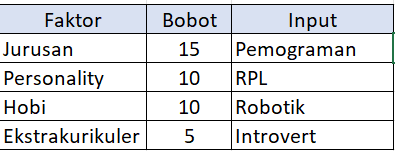

Memberikan Bobot nilai ke detiap bidang yang termasuk kedalam Faktor

* Jurusan = 15 = RPL (Komputer & Teknologi)
* Personality = 10 = Introvert - (Komputer & Teknologi, Seni & Budaya, dan Sains & MIPA)
* Hobi = 10 = Pemograman - (Komputer & Teknologi)
* Ekstrakurikuler = 5 = Robotik (Komputer & Teknologi dan Teknik)


Menghitung nilai bobot di setiap masing masing bidang. Menambahkan hasil Random Forest
yaitu 20

* Komputer dan Teknologi = 15 + 10 + 10 + 5 = 40 + 20 = 60
* Sains dan MIPA = 10
* Seni dan Budaya = 10
* Teknik = 5

Menghitung Presentase
1. Mengjumlahkan Semua skor

Total Skor = 60 + 10 + 10 + 5
           = 85

2. Menghitung Presentase
* Komputer dan Teknologi = 60/85 x 100
                         = 0,7058 x 100
                         = 70,5%

* Sains dan MIPA = 10/85 x 100
                 = 0,117 x 100
                 = 11,7%

* Seni dan Budaya = 10/85 x 100
                  = 0,117 x 100
                  = 11,7%

* Teknik = 5/85 x 100
         = 0,0588 x 100
         = 5,8%

Komputer dan Teknologi : 70%
Teknik :5,8%
Sains dan MIPA : 11,7%
Seni : 11.7%
        

#**1. Knowledge Base**
Sebelum sistem dapat memberikan rekomendasi, dibuat terlebih dahulu basis pengetahuan berupa mapping antara karakteristik siswa dan bidang studi. Hal ini di buat untuk mengadaptasikan dengan pendidikan yang ada di indonesia

**A. Jurusan**

Bertujuan untuk menghubungkan jurusan yang ditempuh siswa di SMA/SMK dengan bidang studi yang relevan. Jurusan dianggap dapat merepresentasikan dasar pengetahuan dan kompetensi yang telah dipelajari oleh siswa.

**B. Personality**

Bertujuan untuk mempertimbangkan karakter dan kecenderungan perilaku siswa dalam menentukan bidang studi yang sesuai. Setiap tipe kepribadian memiliki karakteristik yang dapat mendukung bidang studi tertentu.

**C. Hobi**

Bertujuan untuk mengidentifikasi ketertarikan siswa melalui aktivitas yang dilakukan secara sukarela dan berkelanjutan. Hobi dapat menjadi indikator awal terhadap bidang studi yang diminati siswa.

**D. Ekstrakurikuller**
Bertujuan untuk mempertimbangkan aktivitas non-akademik yang diikuti siswa sebagai indikator minat, pengalaman, dan keterampilan yang telah dikembangkan di luar kegiatan belajar formal.

**A. Jurusan**

In [ ]:
jurusan = {

    "IPA":
     [ "Sains dan MIPA",
        "Kesehatan",
        "Teknik"],

    "IPS": ["Ekonomi dan Bisnis",
            "Sosial dan Humaniora"],

    "Bahasa": ["Pendidikan",
                "Sosial dan Humaniora",
                "Seni"],

    "RPL": ["Komputer dan Teknologi"],
    "TKJ": ["Komputer dan Teknologi"],
    # Sistem Informatika Jaringan dan Aplikasi
    "SIJA": ["Komputer dan Teknologi"],
    # Pengembangan Perangkat Lunak dan Gim
    "PPLG": ["Komputer dan Teknologi"],
    "Rekayasa Perangkat Lunak": ["Komputer dan Teknologi"],

    "Akuntansi": ["Ekonomi dan Bisnis"],
    "AKL": [ "Ekonomi dan Bisnis"],
    "Perbankan": ["Ekonomi dan Bisnis"],
    "Manajemen Perkantoran": ["Ekonomi dan Bisnis"],
    "OTKP": ["Ekonomi dan Bisnis"],
    "Bisnis Daring dan Pemasaran": ["Ekonomi dan Bisnis"],
    "BDP": ["Ekonomi dan Bisnis"],
    "Pemasaran": ["Ekonomi dan Bisnis"],
    "Administrasi Perkantoran": ["Ekonomi dan Bisnis"],
     "Kuliner": ["Ekonomi dan Bisnis"],
    "Tata Boga": ["Ekonomi dan Bisnis"],

    "TKR": ["Teknik"],
    "TBSM": ["Teknik"],
    "Teknik Mesin": ["Teknik"],
    "Teknik Elektro": ["Teknik"],
    "Teknik Kendaraan Ringan": ["Teknik"],
    "Teknik Otomotif": ["Teknik"],
    "Teknik Pengelasan": ["Teknik"],
    "Teknik Pemesinan": ["Teknik"],
    "Teknik Industri": ["Teknik"],
    "Teknik Pendingin dan Tata Udara": ["Teknik"],
    "Teknik Konstruksi": ["Teknik"],
    "Teknik Sipil": ["Teknik"],
    "Teknik Energi Terbarukan": ["Teknik"],
    "Mekatronika": ["Teknik"],
    "Teknik Alat Berat": ["Teknik"],

    "Farmasi": ["Kesehatan"],
    "Keperawatan": ["Kesehatan"],
    "Analis Kesehatan": ["Kesehatan"],
    "Asisten Keperawatan": ["Kesehatan"],

    "Seni Musik": ["Seni"],
    "Seni Tari": ["Seni"],
    "Seni Rupa": ["Seni"],

    "Agribisnis Tanaman": ["Pertanian"],
    "Agribisnis Perikanan": ["Pertanian"],
    "Agribisnis Ternak": ["Pertanian"],
    "Kehutanan": ["Pertanian"],

    "Perhotelan": ["Ekonomi dan Bisnis",
                    "Sosial dan Humaniora"],

    "Broadcasting": ["Seni",
                    "Sosial dan Humaniora"],

    "Multimedia": ["Komputer dan Teknologi",
                    "Seni"],
    "Animasi": ["Komputer dan Teknologi",
                "Seni"],
    "DKV": ["Komputer dan Teknologi",
            "Seni"],

    "Perhotelan": [ "Ekonomi dan Bisnis",
                    "Sosial dan Humaniora"],

    "Desain Komunikasi Visual": ["Komputer dan Teknologi",
                                 "Seni"],

    "Usaha Perjalanan Wisata": ["Sosial dan Humaniora",
                                "Ekonomi dan Bisnis"],

    "Tata Busana": ["Seni",
                   "Ekonomi dan Bisnis"],




}

**B. Personality**

In [ ]:
personality = {

    "Introvert":
        ["Komputer dan Teknologi",
        "Sains dan MIPA",
        "Seni"],

    "Ambivert":
        ["Komputer dan Teknologi",
        "Teknik",
        "Ekonomi dan Bisnis",
        "Pendidikan",
        "Sosial dan Humaniora"],

    "Extrovert":
        ["Ekonomi dan Bisnis",
        "Pendidikan",
        "Sosial dan Humaniora",
        "Kesehatan"]
}

**C. Hobi**

In [ ]:
hobi = {

    # KOMPUTER & TEKNOLOGI
    "bermain game": ["Komputer dan Teknologi"],
    "pemograman": ["Komputer dan Teknologi"],
    "blogging": ["Komputer dan Teknologi", "Sosial dan Humaniora"],

    # TEKNIK
    "merakit": ["Teknik"],
    "catur": ["Teknik"],
    "puzzle": ["Teknik"],
    "robotik": ["Komputer dan Teknologi", "Teknik"],
    "modifikasi": ["Teknik"],

    # KESEHATAN
    "olahraga": ["Kesehatan"],

    # EKONOMI DAN BISNIS
    "bisnis": ["Ekonomi dan Bisnis"],

    # PENDIDIKAN
    "mengajar": ["Pendidikan"],
    "belajar": ["Pendidikan"],
    "belajar bahasa": ["Pendidikan"],
    "membaca buku": ["Pendidikan"],

    # Seni
    "menggambar/melukis": ["Seni"],
    "musik": ["Seni"],
    "menari": ["Seni"],
    "fotografi": ["Seni"],
    "editing video": ["Seni"],
    "animasi": ["Seni"],
    "menulis cerita": ["Seni", "Sosial dan Humaniora"],
    "bermain alat musik": ["Seni"],

    # SOSIAL DAN HUMANIORA
    "menulis": ["Sosial dan Humaniora"],
    "travelling": ["Sosial dan Humaniora"],
    "menonton": ["Sosial dan Humaniora"],
    "debat": ["Sosial dan Humaniora"],
    "organisasi": ["Sosial dan Humaniora"],

    # PERTANIAN
    "berkebun": ["Pertanian"],
    "menanam": ["Pertanian"],
    "bertani": ["Pertanian"],

    # SAINS DAN MIPA
    "eksperimen": ["Sains dan MIPA"],
    "membaca sains": ["Sains dan MIPA"],
    "meneliti": ["Sains dan MIPA"]
}

**D. Ekstrakurikuller**

In [ ]:
ekskul = {

    "programing club": ["Komputer dan Teknologi"],

    "PMR": ["Kesehatan"],
    "oLahraga": ["Kesehatan"],
    "bela diri": ["Kesehatan"],

    "kewirausahaan": ["Ekonomi dan Bisnis"],

    "tutor": ["Pendidikan"],

    "teater": ["Seni"],
    "paduan suara": ["Seni"],
    "keSenian": ["Seni"],
    "desain grafis": ["Seni"],
    "fotografi": ["Seni"],

    "jurnalistik": ["Sosial dan Humaniora"],
    "debat": ["Sosial dan Humaniora"],
    "OSIS": ["Sosial dan Humaniora"],

    "tani sekolah": ["Pertanian"],

    "KIR": ["Sains dan MIPA", "Komputer dan Teknologi"],

    "robotik": ["Komputer dan Teknologi", "Teknik"],

    "english club": ["Pendidikan", "Sosial dan Humaniora"],
    "pramuka": ["Pendidikan", "Sosial dan Humaniora"],
    "paskibra": ["Pendidikan", "Sosial dan Humaniora"],

}

#**2. Insialisasi Skor**
Menyiapkan skor awal untuk setiap bidang studi yang nantinya akan digunakan dalam proses perhitungan dan pemeringkatan rekomendasi.

In [ ]:
#2 Insialisisi Skor
skor = {
    "Komputer dan Teknologi": 0,
    "Teknik": 0,
    "Kesehatan": 0,
    "Ekonomi dan Bisnis": 0,
    "Pendidikan": 0,
    "Seni": 0,
    "Sosial dan Humaniora": 0,
    "Pertanian": 0,
    "Sains dan MIPA": 0
}

#**3. Pemberian Bobot**
Tahap ini digunakan untuk memberikan skor pada setiap bidang studi berdasarkan aturan (rule) yang telah dibuat sebelumnya.

Aturan tersebut berasal dari:


*   Hobi
*   Jurusan
*   Ekstrakurikuler
*   Personality

Setiap faktor memiliki bobot yang berbeda sesuai tingkat pengaruhnya terhadap pemilihan bidang studi.

In [ ]:
pilihan_hobi = "pemograman"
pilihan_jurusan = "RPL"
pilihan_ekskul = "Robotik"
pilihan_personality = "Introvert"

# Hobi (+10)
if pilihan_hobi:
    for bidang in hobi.get(pilihan_hobi, []):
        skor[bidang] += 10

# Jurusan (+15)
if pilihan_jurusan:
    for bidang in jurusan.get(pilihan_jurusan, []):
        skor[bidang] += 15

# Ekskul (+10)
if pilihan_ekskul:
    for bidang in ekskul.get(pilihan_ekskul, []):
        skor[bidang] += 5

# Personality (+5)
if pilihan_personality:
    for bidang in personality.get(pilihan_personality, []):
        skor[bidang] += 10

print(skor)

{'Komputer dan Teknologi': 35, 'Teknik': 0, 'Kesehatan': 0, 'Ekonomi dan Bisnis': 0, 'Pendidikan': 0, 'Seni': 10, 'Sosial dan Humaniora': 0, 'Pertanian': 0, 'Sains dan MIPA': 10}


#**4. Menambahkan Hasil Random Forest**

Menambahkan hasil prediksi model *Random Forest* dengan sistem *Rule Based* yang telah menghasilkan skor pada masing-masing bidang studi.

In [ ]:
#4. menambahkan hasil niali RF
prediksi_rf = le.inverse_transform(prediksi)[0]

print("Prediksi RF:", prediksi_rf)

skor[prediksi_rf] += 20

Prediksi RF: Komputer dan Teknologi


#**5.Rangking**
Mengurutkan seluruh bidang studi berdasarkan skor yang telah diperoleh, mulai dari skor tertinggi hingga skor terendah. Proses ini dilakukan untuk menentukan bidang studi yang paling sesuai dengan karakteristik pengguna.

In [ ]:
ranking = sorted(
    skor.items(),
    key=lambda x: x[1],
    reverse=True
)

print(ranking)

[('Komputer dan Teknologi', 55), ('Seni', 10), ('Sains dan MIPA', 10), ('Teknik', 0), ('Kesehatan', 0), ('Ekonomi dan Bisnis', 0), ('Pendidikan', 0), ('Sosial dan Humaniora', 0), ('Pertanian', 0)]


#**6. Menghitung Presentase**
mengubah skor setiap bidang menjadi bentuk persentase agar hasil rekomendasi lebih mudah dipahami oleh pengguna.

#**7. Rekomendasi 3 Top Bidang**
mengambil 3 bidang studi dengan nilai tertinggi yang telah diperoleh dari proses scoring dan ranking sebelumnya.


#**8. Bidang Utama**
Menampilkan hasil rekomendasi dalam bentuk persentase dan ranking sehingga pengguna dapat mengetahui bidang studi yang paling sesuai beserta beberapa alternatif pilihan bidang lainnya.

In [ ]:
#6.menghitung presentase
total_skor = sum(skor.values())
hasil = []

for bidang, nilai in ranking:
    persentase = round((nilai / total_skor) * 100, 2)

    hasil.append((bidang, nilai, persentase))

# 7.menghitung 3 bidang rekomendasi
    top_3 = hasil[:3]

for bidang, nilai, persen in top_3:
    print(bidang, "-", persen, "%")

#8.rekomendasi bidang utama
    bidang_utama = hasil[0][0]

#menambahkan prediksi Random Forest
skor[prediksi_rf] += 20

print("Bidang Studi Utama:",bidang_utama)

Komputer dan Teknologi - 73.33 %
Seni - 13.33 %
Sains dan MIPA - 13.33 %
Bidang Studi Utama: Komputer dan Teknologi


#**Uji Coba 2**

In [ ]:
# INPUT USER 1
siswa_baru = """
accounting
finance
business
marketing
communication
"""

pilihan_hobi = "bisnis"
pilihan_jurusan = "AKL"
pilihan_ekskul = "Kewirausahaan"
pilihan_personality = "Extrovert"


# PREDIKSI RANDOM FOREST

X_baru = tfidf.transform([siswa_baru])

prediksi = rf.predict(X_baru)

prediksi_rf = le.inverse_transform(prediksi)[0]


# SCORING
skor = {
    "Komputer dan Teknologi": 0,
    "Teknik": 0,
    "Kesehatan": 0,
    "Ekonomi dan Bisnis": 0,
    "Pendidikan": 0,
    "Seni": 0,
    "Sosial dan Humaniora": 0,
    "Pertanian": 0,
    "Sains dan MIPA": 0
}


# Hobi
for bidang in hobi.get(pilihan_hobi, []):
    skor[bidang] += 10

# Jurusan
for bidang in jurusan.get(pilihan_jurusan, []):
    skor[bidang] += 15

# Ekskul
for bidang in ekskul.get(pilihan_ekskul, []):
    skor[bidang] += 5

# Personality
for bidang in personality.get(pilihan_personality, []):
    skor[bidang] += 10


# memprediksi menggunakan RANDOM FOREST
skor[prediksi_rf] += 20


# HASIL AKHIR
#merekomendasikan berdasarkan 3 top
ranking = sorted(skor.items(), key=lambda x: x[1], reverse=True)

total = sum(skor.values())

print("HASIL REKOMENDASI\n")
print("Prediksi RF :", prediksi_rf)
for bidang, nilai in ranking[:3]:
    persen = round((nilai/total)*100, 2)
    print(bidang,"-", persen, "%")



HASIL REKOMENDASI

Prediksi RF : Ekonomi dan Bisnis
Ekonomi dan Bisnis - 64.71 %
Kesehatan - 11.76 %
Pendidikan - 11.76 %


In [ ]:
# INPUT USER 2
siswa_baru = """
programming
python
machine learning
data science
problem solving
"""

pilihan_hobi = "pemograman"
pilihan_jurusan = "RPL"
pilihan_ekskul = "Robotik"
pilihan_personality = "Introvert"


# PREDIKSI RANDOM FOREST
X_baru = tfidf.transform([siswa_baru])

prediksi = rf.predict(X_baru)

prediksi_rf = le.inverse_transform(prediksi)[0]


# SCORING
skor = {
    "Komputer dan Teknologi": 0,
    "Teknik": 0,
    "Kesehatan": 0,
    "Ekonomi dan Bisnis": 0,
    "Pendidikan": 0,
    "Seni": 0,
    "Sosial dan Humaniora": 0,
    "Pertanian": 0,
    "Sains dan MIPA": 0
}

# Hobi
for bidang in hobi.get(pilihan_hobi, []):
    skor[bidang] += 10

# Jurusan
for bidang in jurusan.get(pilihan_jurusan, []):
    skor[bidang] += 15

# Ekskul
for bidang in ekskul.get(pilihan_ekskul, []):
    skor[bidang] += 5

# Personality
for bidang in personality.get(pilihan_personality, []):
    skor[bidang] += 10


# memprediksi menggunakan RANDOM FOREST
skor[prediksi_rf] += 20


# HASIL AKHIR
#merekomendasikan berdasarkan 3 top
ranking = sorted(skor.items(), key=lambda x: x[1], reverse=True)

total = sum(skor.values())

print("HASIL REKOMENDASI\n")
print("Prediksi RF :", prediksi_rf)
for bidang, nilai in ranking[:3]:
    persen = round((nilai/total)*100, 2)
    print(bidang,"-", persen, "%")

In [ ]:
# INPUT USER 3
siswa_baru = """
web development
database
java
networking
software engineering
"""

pilihan_hobi = "bermain game"
pilihan_jurusan = "TKJ"
pilihan_ekskul = "Programing Club"
pilihan_personality = "Extrovert"


# PREDIKSI RANDOM FOREST

X_baru = tfidf.transform([siswa_baru])

prediksi = rf.predict(X_baru)

prediksi_rf = le.inverse_transform(prediksi)[0]


# SCORING
skor = {
    "Komputer dan Teknologi": 0,
    "Teknik": 0,
    "Kesehatan": 0,
    "Ekonomi dan Bisnis": 0,
    "Pendidikan": 0,
    "Seni": 0,
    "Sosial dan Humaniora": 0,
    "Pertanian": 0,
    "Sains dan MIPA": 0
}


# Hobi
for bidang in hobi.get(pilihan_hobi, []):
    skor[bidang] += 10

# Jurusan
for bidang in jurusan.get(pilihan_jurusan, []):
    skor[bidang] += 15

# Ekskul
for bidang in ekskul.get(pilihan_ekskul, []):
    skor[bidang] += 5

# Personality
for bidang in personality.get(pilihan_personality, []):
    skor[bidang] += 10


# memprediksi menggunakan RANDOM FOREST
skor[prediksi_rf] += 20


# HASIL AKHIR
#merekomendasikan berdasarkan 3 top
ranking = sorted(skor.items(), key=lambda x: x[1], reverse=True)

total = sum(skor.values())

print("HASIL REKOMENDASI\n")
print("Prediksi RF :", prediksi_rf)
for bidang, nilai in ranking[:3]:
    persen = round((nilai/total)*100, 2)
    print(bidang,"-", persen, "%")



In [ ]:
# INPUT USER 4
siswa_baru = """
mechanical design
engineering drawing
manufacturing
cad
mechanics
"""

pilihan_hobi = "merakit"
pilihan_jurusan = "Teknik Mesin"
pilihan_ekskul = "Robotik"
pilihan_personality = "Ambivert"


# PREDIKSI RANDOM FOREST

X_baru = tfidf.transform([siswa_baru])

prediksi = rf.predict(X_baru)

prediksi_rf = le.inverse_transform(prediksi)[0]


# SCORING
skor = {
    "Komputer dan Teknologi": 0,
    "Teknik": 0,
    "Kesehatan": 0,
    "Ekonomi dan Bisnis": 0,
    "Pendidikan": 0,
    "Seni": 0,
    "Sosial dan Humaniora": 0,
    "Pertanian": 0,
    "Sains dan MIPA": 0
}


# Hobi
for bidang in hobi.get(pilihan_hobi, []):
    skor[bidang] += 10

# Jurusan
for bidang in jurusan.get(pilihan_jurusan, []):
    skor[bidang] += 15

# Ekskul
for bidang in ekskul.get(pilihan_ekskul, []):
    skor[bidang] += 5

# Personality
for bidang in personality.get(pilihan_personality, []):
    skor[bidang] += 10


# memprediksi menggunakan RANDOM FOREST
skor[prediksi_rf] += 20


# HASIL AKHIR
#merekomendasikan berdasarkan 3 top
ranking = sorted(skor.items(), key=lambda x: x[1], reverse=True)

total = sum(skor.values())

print("HASIL REKOMENDASI\n")
print("Prediksi RF :", prediksi_rf)
for bidang, nilai in ranking[:3]:
    persen = round((nilai/total)*100, 2)
    print(bidang,"-", persen, "%")

In [ ]:
# INPUT USER 5
siswa_baru = """
accounting
finance
business
marketing
communication
"""

pilihan_hobi = "bisnis"
pilihan_jurusan = "AKL"
pilihan_ekskul = "Kewirausahaan"
pilihan_personality = "Extrovert"

# PREDIKSI RANDOM FOREST

X_baru = tfidf.transform([siswa_baru])

prediksi = rf.predict(X_baru)

prediksi_rf = le.inverse_transform(prediksi)[0]


# SCORING
skor = {
    "Komputer dan Teknologi": 0,
    "Teknik": 0,
    "Kesehatan": 0,
    "Ekonomi dan Bisnis": 0,
    "Pendidikan": 0,
    "Seni": 0,
    "Sosial dan Humaniora": 0,
    "Pertanian": 0,
    "Sains dan MIPA": 0
}


# Hobi
for bidang in hobi.get(pilihan_hobi, []):
    skor[bidang] += 10

# Jurusan
for bidang in jurusan.get(pilihan_jurusan, []):
    skor[bidang] += 15

# Ekskul
for bidang in ekskul.get(pilihan_ekskul, []):
    skor[bidang] += 5

# Personality
for bidang in personality.get(pilihan_personality, []):
    skor[bidang] += 10


# memprediksi menggunakan RANDOM FOREST
skor[prediksi_rf] += 20


# HASIL AKHIR
#merekomendasikan berdasarkan 3 top
ranking = sorted(skor.items(), key=lambda x: x[1], reverse=True)

total = sum(skor.values())

print("HASIL REKOMENDASI\n")
print("Prediksi RF :", prediksi_rf)
for bidang, nilai in ranking[:3]:
    persen = round((nilai/total)*100, 2)
    print(bidang,"-", persen, "%")

In [ ]:
# INPUT USER 6
siswa_baru = """
teaching
learning
education
public speaking
communication
"""

pilihan_hobi = "mengajar"
pilihan_jurusan = "Bahasa"
pilihan_ekskul = "Tutor Sebaya"
pilihan_personality = "Extrovert"

# PREDIKSI RANDOM FOREST

X_baru = tfidf.transform([siswa_baru])

prediksi = rf.predict(X_baru)

prediksi_rf = le.inverse_transform(prediksi)[0]


# SCORING
skor = {
    "Komputer dan Teknologi": 0,
    "Teknik": 0,
    "Kesehatan": 0,
    "Ekonomi dan Bisnis": 0,
    "Pendidikan": 0,
    "Seni": 0,
    "Sosial dan Humaniora": 0,
    "Pertanian": 0,
    "Sains dan MIPA": 0
}


# Hobi
for bidang in hobi.get(pilihan_hobi, []):
    skor[bidang] += 10

# Jurusan
for bidang in jurusan.get(pilihan_jurusan, []):
    skor[bidang] += 15

# Ekskul
for bidang in ekskul.get(pilihan_ekskul, []):
    skor[bidang] += 5

# Personality
for bidang in personality.get(pilihan_personality, []):
    skor[bidang] += 10


# memprediksi menggunakan RANDOM FOREST
skor[prediksi_rf] += 20


# HASIL AKHIR
#merekomendasikan berdasarkan 3 top
ranking = sorted(skor.items(), key=lambda x: x[1], reverse=True)

total = sum(skor.values())

print("HASIL REKOMENDASI\n")
print("Prediksi RF :", prediksi_rf)
for bidang, nilai in ranking[:3]:
    persen = round((nilai/total)*100, 2)
    print(bidang,"-", persen, "%")

In [ ]:
# INPUT USER 7
siswa_baru = """
graphic design
animation
creative thinking
illustration
multimedia
"""

pilihan_hobi = "menggambar/melukis"
pilihan_jurusan = "Multimedia"
pilihan_ekskul = "Desain Grafis"
pilihan_personality = "Introvert"

# PREDIKSI RANDOM FOREST

X_baru = tfidf.transform([siswa_baru])

prediksi = rf.predict(X_baru)

prediksi_rf = le.inverse_transform(prediksi)[0]


# SCORING
skor = {
    "Komputer dan Teknologi": 0,
    "Teknik": 0,
    "Kesehatan": 0,
    "Ekonomi dan Bisnis": 0,
    "Pendidikan": 0,
    "Seni": 0,
    "Sosial dan Humaniora": 0,
    "Pertanian": 0,
    "Sains dan MIPA": 0
}


# Hobi
for bidang in hobi.get(pilihan_hobi, []):
    skor[bidang] += 10

# Jurusan
for bidang in jurusan.get(pilihan_jurusan, []):
    skor[bidang] += 15

# Ekskul
for bidang in ekskul.get(pilihan_ekskul, []):
    skor[bidang] += 5

# Personality
for bidang in personality.get(pilihan_personality, []):
    skor[bidang] += 10


# memprediksi menggunakan RANDOM FOREST
skor[prediksi_rf] += 20


# HASIL AKHIR
#merekomendasikan berdasarkan 3 top
ranking = sorted(skor.items(), key=lambda x: x[1], reverse=True)

total = sum(skor.values())

print("HASIL REKOMENDASI\n")
print("Prediksi RF :", prediksi_rf)
for bidang, nilai in ranking[:3]:
    persen = round((nilai/total)*100, 2)
    print(bidang,"-", persen, "%")

In [ ]:
# INPUT USER 8
siswa_baru = """
law
communication
journalism
social analysis
public policy
"""

pilihan_hobi = "debat"
pilihan_jurusan = "IPS"
pilihan_ekskul = "Jurnalistik"
pilihan_personality = "Extrovert"

# PREDIKSI RANDOM FOREST

X_baru = tfidf.transform([siswa_baru])

prediksi = rf.predict(X_baru)

prediksi_rf = le.inverse_transform(prediksi)[0]


# SCORING
skor = {
    "Komputer dan Teknologi": 0,
    "Teknik": 0,
    "Kesehatan": 0,
    "Ekonomi dan Bisnis": 0,
    "Pendidikan": 0,
    "Seni": 0,
    "Sosial dan Humaniora": 0,
    "Pertanian": 0,
    "Sains dan MIPA": 0
}


# Hobi
for bidang in hobi.get(pilihan_hobi, []):
    skor[bidang] += 10

# Jurusan
for bidang in jurusan.get(pilihan_jurusan, []):
    skor[bidang] += 15

# Ekskul
for bidang in ekskul.get(pilihan_ekskul, []):
    skor[bidang] += 5

# Personality
for bidang in personality.get(pilihan_personality, []):
    skor[bidang] += 10


# memprediksi menggunakan RANDOM FOREST
skor[prediksi_rf] += 15


# HASIL AKHIR
#merekomendasikan berdasarkan 3 top
ranking = sorted(skor.items(), key=lambda x: x[1], reverse=True)

total = sum(skor.values())

print("HASIL REKOMENDASI\n")
print("Prediksi RF :", prediksi_rf)
for bidang, nilai in ranking[:3]:
    persen = round((nilai/total)*100, 2)
    print(bidang,"-", persen, "%")

In [ ]:
# INPUT USER 9
siswa_baru = """
research
mathematics
physics
chemistry
scientific analysis
"""

pilihan_hobi = "eksperimen"
pilihan_jurusan = "IPA"
pilihan_ekskul = "KIR"
pilihan_personality = "Introvert"

# PREDIKSI RANDOM FOREST

X_baru = tfidf.transform([siswa_baru])

prediksi = rf.predict(X_baru)

prediksi_rf = le.inverse_transform(prediksi)[0]


# SCORING
skor = {
    "Komputer dan Teknologi": 0,
    "Teknik": 0,
    "Kesehatan": 0,
    "Ekonomi dan Bisnis": 0,
    "Pendidikan": 0,
    "Seni": 0,
    "Sosial dan Humaniora": 0,
    "Pertanian": 0,
    "Sains dan MIPA": 0
}


# Hobi
for bidang in hobi.get(pilihan_hobi, []):
    skor[bidang] += 10

# Jurusan
for bidang in jurusan.get(pilihan_jurusan, []):
    skor[bidang] += 15

# Ekskul
for bidang in ekskul.get(pilihan_ekskul, []):
    skor[bidang] += 5

# Personality
for bidang in personality.get(pilihan_personality, []):
    skor[bidang] += 10


# memprediksi menggunakan RANDOM FOREST
skor[prediksi_rf] += 15


# HASIL AKHIR
#merekomendasikan berdasarkan 3 top
ranking = sorted(skor.items(), key=lambda x: x[1], reverse=True)

total = sum(skor.values())

print("HASIL REKOMENDASI\n")
print("Prediksi RF :", prediksi_rf)
for bidang, nilai in ranking[:3]:
    persen = round((nilai/total)*100, 2)
    print(bidang,"-", persen, "%")